# 特征工程 及 探索性分析
首先对项目进行一个简要的介绍。用户通过运行下面的第一个Python代码块获取了B站的原始评论数据，包括用户昵称、性别、评论内容、被回复用户、评论层级、用户当前等级、点赞数量、二级评论数、回复时间。然后通过下面的代码进行NLP特征提取、然后探索性分析（EDA）。


## 第一步 配置环境
下载库文件

In [9]:
pip install -r requirements.txt

Looking in indexes: https://mirrors.huaweicloud.com/repository/pypi/simple
     ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
     -------------------------- ----------- 524.3/756.0 kB 3.4 MB/s eta 0:00:01
     -------------------------------------- 756.0/756.0 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 第二步 运行下方代码，爬取一段时间的文件

In [ ]:
import requests
import re
import time
import os
from openpyxl import Workbook, load_workbook
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urlparse

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
}

def get_popular_videos():
    # API地址
    url = "https://api.bilibili.com/x/web-interface/popular"
    read_list=[]

    try:
        # 发送GET请求
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # 检查请求是否成功
        
        data = response.json()
        
        # 提取视频列表
        video_list = data.get('data', {}).get('list', [])

        for video in video_list:
            title = video.get('title', '')
            short_link = video.get('short_link_v2', '')
            
            # 从短链接中提取BV号
            bv_id = urlparse(short_link).path.split('/')[-1] if short_link else ''

            read_list.append((title,bv_id))
        
        return read_list
        
    except requests.exceptions.RequestException as e:
        print(f"请求失败: {e}")
    except ValueError as e:
        print(f"JSON解析失败: {e}")
    except Exception as e:
        print(f"发生错误: {e}")

def get_video_id(bv):
    url = f'https://www.bilibili.com/video/{bv}'
    html = requests.get(url, headers=headers)
    html.encoding = 'utf-8'
    content = html.text
    aid_regx = '"aid":(.*?),"bvid":"{}"'.format(bv)
    video_aid = re.findall(aid_regx, content)[0]
    return video_aid


def fetch_comment_replies(video_id, comment_id, parent_user_name, max_pages=20):
    replies = []
    preLen = 0
    for page in range(1, max_pages + 1):
        url = f'https://api.bilibili.com/x/v2/reply/reply?oid={video_id}&type=1&root={comment_id}&ps=10&pn={page}'
        try:
            # 添加超时设置
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                if data and data.get('data') and data['data'].get('replies'):
                    for reply in data['data']['replies']:
                        reply_info = {
                            '用户昵称': reply['member']['uname'],
                            '评论内容': reply['content']['message'],
                            '被回复用户': parent_user_name,
                            '评论层级': '二级评论',
                            '性别': reply['member']['sex'],
                            '用户当前等级': reply['member']['level_info']['current_level'],
                            '点赞数量': reply['like'],
                            '回复时间': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(reply['ctime']))
                        }
                        replies.append(reply_info)
                    if preLen == len(replies):
                        break
                    preLen = len(replies)
                else:
                    return replies
        except requests.RequestException as e:
            print(f"请求出错: {e}")
            break
        # 控制请求频率
        time.sleep(1)
    return replies


def fetch_comments(video_id, max_pages=20):
    comments = []
    last_count = 0
    for page in range(1, max_pages + 1):
        url = f'https://api.bilibili.com/x/v2/reply?pn={page}&type=1&oid={video_id}&sort=2'
        try:
            # 添加超时设置
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                if data and data.get('data') and data['data'].get('replies'):
                    for comment in data['data']['replies']:
                        comment_info = {
                            '用户昵称': comment['member']['uname'],
                            '评论内容': comment['content']['message'],
                            '被回复用户': '',
                            '评论层级': '一级评论',
                            '性别': comment['member']['sex'],
                            '用户当前等级': comment['member']['level_info']['current_level'],
                            '点赞数量': comment['like'],
                            '回复时间': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(comment['ctime']))
                        }
                        print(comment_info)
                        comments.append(comment_info)
                        replies = fetch_comment_replies(video_id, comment['rpid'], comment['member']['uname'])
                        comments.extend(replies)
                if last_count == len(comments):
                    break
                last_count = len(comments)
            else:
                break
        except requests.RequestException as e:
            print(f"请求出错: {e}")
            break
        # 控制请求频率
        time.sleep(1)
    return comments

def get_unique_filename(base_name, extension=".xlsx"):
    base_name = base_name.split('.')[1]
    counter = 1
    filename = f".{base_name}{extension}"
    while os.path.exists(filename):
        filename = f".{base_name}_{counter}{extension}"
        counter += 1
    return filename

def save_comments_to_excel(comments, video_name, workbook, video_bv):
    if (video_bv in workbook.sheetnames):
        sheet = workbook[video_bv]
    else:
        sheet = workbook.create_sheet(title=video_bv)
        sheet.append(['用户昵称', '性别', '评论内容', '被回复用户', '评论层级', '用户当前等级', '点赞数量', '回复时间', video_name])
    
    for comment in comments:
        sheet.append([
            comment['用户昵称'], comment['性别'], comment['评论内容'], comment['被回复用户'],
            comment['评论层级'], comment['用户当前等级'], comment['点赞数量'], comment['回复时间']
        ])

def fetch_and_save_comments(video_name, video_bv, workbook):
    print(f'视频名字: {video_name}, video_bv: {video_bv}')
    aid = get_video_id(video_bv)
    video_id = aid
    comments = fetch_comments(video_id)
    save_comments_to_excel(comments, video_name, workbook, video_bv)

filename = './video_list.csv'
output_filename = './result/comment_output_0.xlsx'
max_threads = 1  # 可以调整的线程数

if __name__ == '__main__':

    # 创建工作簿
    workbook = Workbook()
    workbook.remove(workbook.active)  # 删除默认的Sheet

    #获取热点视频
    video_list = get_popular_videos()

    # 使用线程池并行抓取评论
    with ThreadPoolExecutor(max_workers=max_threads) as executor:
        futures = [executor.submit(fetch_and_save_comments, video_name, video_bv, workbook) for video_name, video_bv in video_list]
        for future in as_completed(futures):
            try:
                future.result()
            except Exception as e:
                print(f"线程执行出错: {e}")

    # 保存工作簿
    output_filename = get_unique_filename(output_filename)
    workbook.save(output_filename)


视频名字: 《鸣潮》2.2版本PV | 真伪倒悬于高塔, video_bv: BV1MKXrYvEgJ
{'用户昵称': '空无-天殛', '评论内容': '04:55 不喜欢摁闪避得小朋友们大家好啊，我是超雄古龙，是的孩子们，我进全息了[星星眼]', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 6, '点赞数量': 87, '回复时间': '2025-03-21 20:05:35'}
{'用户昵称': 'RE宵衣', '评论内容': '偶内盖！瓦塔西[颂乐人偶_眯眼笑][颂乐人偶_眯眼笑][颂乐人偶_眯眼笑]', '被回复用户': '', '评论层级': '一级评论', '性别': '男', '用户当前等级': 5, '点赞数量': 34, '回复时间': '2025-03-21 20:22:48'}
{'用户昵称': '我家壶还蛮大的', '评论内容': 'https://b23.tv/BV1EEXNYDEmG', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 6, '点赞数量': 11, '回复时间': '2025-03-21 20:14:03'}
视频名字: 谁是德国最强刺客？【硬核狠人79】, video_bv: BV1mzXAYtEjS
{'用户昵称': '赤色汤姆', '评论内容': '我宣布，本期主角放通辽宇宙中，都算是狠人第一梯队的翘楚。', '被回复用户': '', '评论层级': '一级评论', '性别': '保密', '用户当前等级': 6, '点赞数量': 2006, '回复时间': '2025-03-21 13:24:18'}
{'用户昵称': '灵狼皇', '评论内容': '我还以为是爆炸没成功，或者被发现了，或者希特勒根本没去。\n结果是因为希特勒当天状态不好...只能说谋事在人成事在天', '被回复用户': '', '评论层级': '一级评论', '性别': '男', '用户当前等级': 6, '点赞数量': 1108, '回复时间': '2025-03-21 14:24:38'}
{'用户昵称': 'dgffgffv', '评论内容': '如果埃尔赛成功了，那么他会从绝对英雄变成有争议的英雄，而老希反倒从恶魔变成8分好

### 运行下方代码，检查xlsx数据是否够用


In [2]:
import os,time
import pandas as pd

# 获取result文件夹中的文件信息
result_folder = './result'
files = []
for file_name in os.listdir(result_folder):
    if file_name.endswith('.xlsx'):
        file_path = os.path.join(result_folder, file_name)
        file_info = {
            '文件名': file_name,
            '日期': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(file_path))),
            '大小': f"{os.path.getsize(file_path) / 1024:.2f} KB"
        }
        files.append(file_info)

# 创建DataFrame并显示
df_files = pd.DataFrame(files)
df_files

,文件名,日期,大小
0,comment_output.xlsx,2025-03-18 17:32:12,37.84 KB
1,comment_output_1.xlsx,2025-03-18 17:40:45,37.86 KB
2,comment_output_2.xlsx,2025-03-19 16:50:46,41.89 KB
3,comment_output_3.xlsx,2025-03-21 23:55:09,34.17 KB


## 第三步 生成各类图像
### 1.点赞时段热度权重图

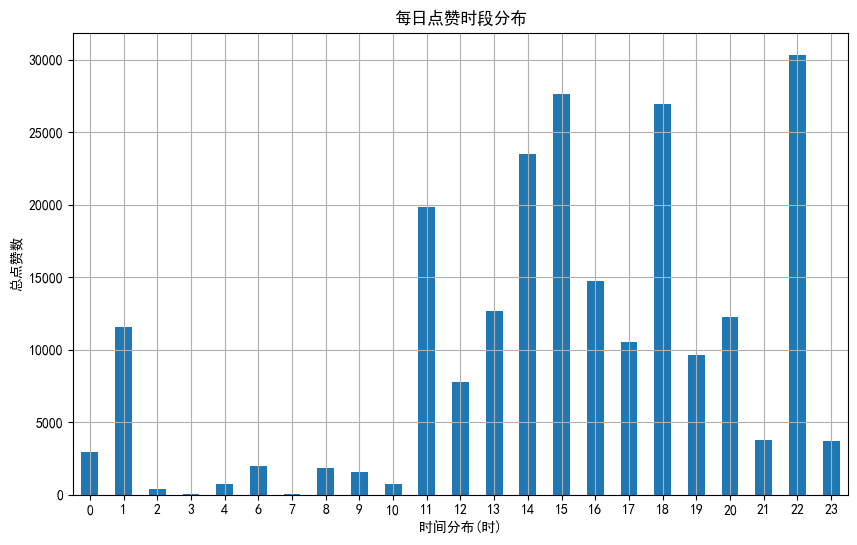

In [31]:
import pandas as pd
from openpyxl import load_workbook

import matplotlib.pyplot as plt

# 定义一个函数来提取数据
def extract_data(file_path):
    data = []
    workbook = load_workbook(file_path)
    for sheet_name in workbook.sheetnames:
        sheet = workbook[sheet_name]
        for row in sheet.iter_rows(min_row=2, values_only=True):
            reply_time = row[7]  # 假设"回复时间"在第8列
            likes = row[6]  # 假设"点赞数"在第7列
            if reply_time and likes:
                hour = pd.to_datetime(reply_time).hour
                data.append((hour, likes))
    return data

# 遍历所有文件并提取数据
all_data = []
for file_info in files:
    file_path = os.path.join(result_folder, file_info['文件名'])
    if file_path.endswith('.xlsx'):
        all_data.extend(extract_data(file_path))

# 创建DataFrame
df_all_data = pd.DataFrame(all_data, columns=['Hour', 'Likes'])

# 按小时分组并计算点赞数总和
hourly_likes = df_all_data.groupby('Hour')['Likes'].sum()

# 绘制时段点赞分布图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(10, 6))
hourly_likes.plot(kind='bar')
plt.xlabel('时间分布(时)')
plt.ylabel('总点赞数')
plt.title('每日点赞时段分布')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

### 2.生成交互评论网络图

In [32]:
import os
from openpyxl import load_workbook
from pyvis.network import Network
from IPython.core.display import display, HTML
import webbrowser  # 用于自动打开浏览器

# 定义根节点名称
ROOT_NODE = "Output"

# 遍历 result 文件夹中的所有文件
result_folder = "result"
files = [{"文件名": f} for f in os.listdir(result_folder) if f.endswith(".xlsx")]

# 遍历所有文件并生成交互式的评论网络图
def generate_interactive_network(files, result_folder, output_html="interactive_network.html"):
    # 创建一个 Pyvis 网络图
    net = Network(height="750px", width="100%", directed=True)
    
    # 添加根节点
    net.add_node(ROOT_NODE, label=ROOT_NODE, color="red", shape="circle", size=30)
    
    for file_info in files:
        file_path = os.path.join(result_folder, file_info['文件名'])
        workbook = load_workbook(file_path, data_only=True)
        
        # 提取表格序号（从文件名中获取）
        table_index = file_info['文件名'].split('_')[-1].split('.')[0] if '_' in file_info['文件名'] else '0'
        table_node = f"Table {table_index}"
        
        # 添加表格序号节点
        net.add_node(table_node, label=table_node, color="orange", shape="circle", size=20)
        net.add_edge(ROOT_NODE, table_node)
        
        # 遍历每个表格的 Sheet
        for sheet_name in workbook.sheetnames:
            sheet = workbook[sheet_name]
            
            # 获取视频名称（I1 单元格内容）
            video_name = sheet["I1"].value
            if not video_name:
                continue  # 如果视频名称为空，跳过
            
            # 如果视频标题过长，省略显示
            display_name = video_name if len(video_name) <= 15 else video_name[:12] + "..."
            
            # 添加视频名称节点
            net.add_node(video_name, label=display_name, title=video_name, color="skyblue", shape="circle", size=20)
            net.add_edge(table_node, video_name)
            
            # 遍历表格内容，提取评论数据
            for row in sheet.iter_rows(min_row=2, values_only=True):
                user_name = row[0]  # A列：评论用户
                comment_content = row[2]  # C列：评论内容
                comment_level = row[4]  # E列：评论层级
                replied_user = row[3]  # D列：被评论用户
                
                if comment_level == "一级评论":
                    # 添加一级评论用户节点
                    net.add_node(
                        user_name,
                        label=user_name,
                        title=comment_content,  # 鼠标悬停显示评论内容
                        color="lightgreen",
                        shape="dot",
                        size=15
                    )
                    net.add_edge(video_name, user_name)
                elif comment_level == "二级评论" and replied_user:
                    # 添加二级评论用户节点，并链接到一级评论用户
                    net.add_node(
                        user_name,
                        label=user_name,
                        title=comment_content,  # 鼠标悬停显示评论内容
                        color="lightblue",
                        shape="dot",
                        size=10
                    )
                    net.add_edge(replied_user, user_name)
    
    # 设置逐层渲染（通过 pyvis 的 physics 属性实现）
    net.toggle_physics(True)
    
    # 调整物理引擎参数，防止节点挤在一起
    net.set_options("""
    var options = {
      "physics": {
        "barnesHut": {
          "gravitationalConstant": -2000,
          "centralGravity": 0.3,
          "springLength": 95,
          "springConstant": 0.04,
          "damping": 0.09
        },
        "minVelocity": 0.75
      },
      "interaction": {
        "tooltipDelay": 200
      }
    }
    """)
    
    # 保存为 HTML 文件
    net.write_html(output_html)
    print(f"交互式网络图已保存为 {output_html}")

    # 自动在浏览器中打开 HTML 文件
    webbrowser.open(output_html)

# 调用函数生成交互式网络图
generate_interactive_network(files, result_folder, output_html="interactive_network.html")

C:\Users\33223\AppData\Local\Temp\ipykernel_42088\2245434934.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


交互式网络图已保存为 interactive_network.html


### 3.生成一级评论点赞数-二级评论数分布图

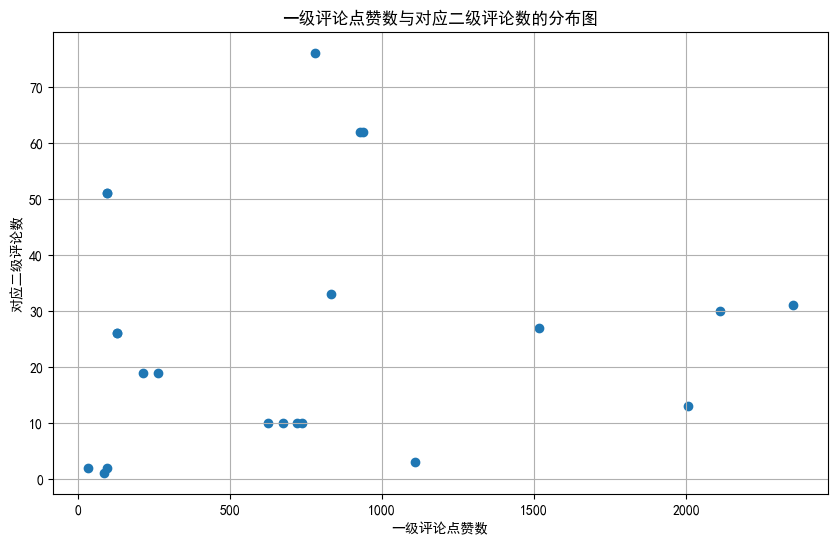

In [12]:
import pandas as pd
from openpyxl import load_workbook
import networkx as nx
import os

import matplotlib.pyplot as plt

# 定义一个函数来提取数据
def extract_comments(file_path):
    comments = []
    workbook = load_workbook(file_path)
    for sheet_name in workbook.sheetnames:
        sheet = workbook[sheet_name]
        for row in sheet.iter_rows(min_row=2, values_only=True):
            comment_info = {
                '用户昵称': row[0],
                '性别': row[1],
                '评论内容': row[2],
                '被回复用户': row[3],
                '评论层级': row[4],
                '用户当前等级': row[5],
                '点赞数量': row[6],
                '回复时间': row[7],
                '视频名称': sheet_name
            }
            comments.append(comment_info)
    return comments

# 遍历所有文件并提取数据
all_comments = []
for file_info in files:
    file_path = os.path.join(result_folder, file_info['文件名'])
    if file_path.endswith('.xlsx'):
        all_comments.extend(extract_comments(file_path))

# 创建DataFrame
df_comments = pd.DataFrame(all_comments)

# 过滤出一级评论和二级评论
df_primary_comments = df_comments[df_comments['评论层级'] == '一级评论']
df_secondary_comments = df_comments[df_comments['评论层级'] == '二级评论']

# 计算一级评论点赞数与对应二级评论数的分布
primary_likes_secondary_count = df_secondary_comments.groupby('被回复用户').size().reset_index(name='二级评论数')
primary_likes_secondary_count = primary_likes_secondary_count.merge(df_primary_comments[['用户昵称', '点赞数量']], left_on='被回复用户', right_on='用户昵称', how='left')
primary_likes_secondary_count = primary_likes_secondary_count[['用户昵称', '点赞数量', '二级评论数']]

# 绘制分布图
plt.figure(figsize=(10, 6))
plt.scatter(primary_likes_secondary_count['点赞数量'], primary_likes_secondary_count['二级评论数'])
plt.xlabel('一级评论点赞数')
plt.ylabel('对应二级评论数')
plt.title('一级评论点赞数与对应二级评论数的分布图')
plt.grid(True)
plt.show()